In [ ]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [6]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
df = pd.read_excel("../data/raw/6S_AI_TASK-Loan_default_Loan_default.xlsx")

In [4]:
target_col = 'Default'
id_col = 'LoanID'

X = df.drop(columns=[target_col, id_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
preprocessor = joblib.load("../models/preprocessor.joblib")

In [8]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

X_train_transformed = preprocessor.transform(train_df)
X_test_transformed = preprocessor.transform(test_df)

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_transformed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
y_pred = model.predict(X_test_transformed)
y_proba = model.predict_proba(X_test_transformed)[:, 1]

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8869931439764936
Precision: 0.6146131805157593
Recall: 0.07235621521335807
F1 Score: 0.1294703485740154
ROC-AUC: 0.7599708703281003


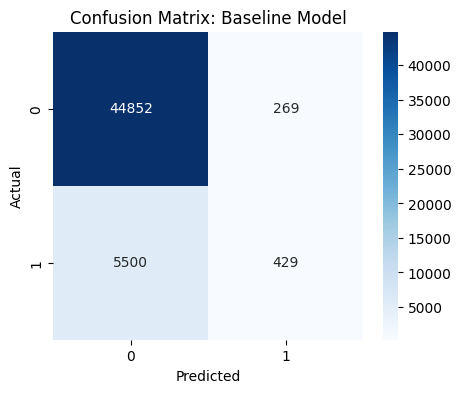

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Baseline Model')
plt.show()

### Confusion Matrix Breakdown
- TN (Correct Non-defaults) → 44,852 
- FP (False alarms) → 269
- FN (Missed defaulters) → 5,500 
- TP (Correct defaulters) → 429


| Metric           | Why                                           |
| ---------------- | --------------------------------------------- |
| Accuracy ≈ 88.7% | Dominated by majority class                   |
| Precision ≈ 0.61 | When it predicts default, it's somewhat right |
| Recall ≈ 0.072   | But it rarely predicts default                |
| F1 ≈ 0.13        | Poor balance                                  |
| ROC-AUC ≈ 0.76   | Model has signal, but threshold is wrong      |

* Recall = 0.072  → You are catching only 7.2% of defaulters

## Possible Reason:
Default threshold in Logistic Regression:

    Predict 1 if probability > 0.5

But data is:

    Only ~11% defaults

So Very few samples cross 0.5 → almost no positive predictions


In [15]:
import numpy as np

thresholds = np.arange(0.1, 0.6, 0.05)

results = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    
    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
results_df

,Threshold,Precision,Recall,F1
0,0.10,0.209805,0.751391,0.328020
1,0.15,0.266356,0.587789,0.366591
2,0.20,0.319725,0.446450,0.372607
3,0.25,0.374362,0.333952,0.353004
4,0.30,0.430246,0.247597,0.314313
5,0.35,0.482295,0.181481,0.263725
6,0.40,0.529142,0.136279,0.216738
7,0.45,0.569185,0.097824,0.166955
8,0.50,0.614613,0.072356,0.129470
9,0.55,0.656842,0.052623,0.097439


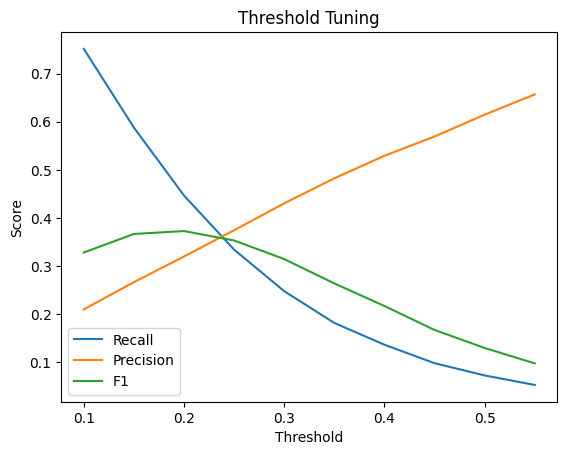

In [16]:
import matplotlib.pyplot as plt

plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['F1'], label='F1')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Threshold Tuning")
plt.show()

In [19]:
y_pred_thresh = (y_proba >= 0.20).astype(int)
    
precision = precision_score(y_test, y_pred_thresh)
recall = recall_score(y_test, y_pred_thresh)
f1 = f1_score(y_test, y_pred_thresh)

print(f"At threshold 0.20: Precision={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")

At threshold 0.20: Precision=0.32, Recall=0.45, F1=0.37


The baseline model had extremely low recall due to the default threshold of 0.5. By lowering the threshold to 0.2, recall improved significantly, capturing more defaulters at the cost of precision. This trade-off is acceptable in risk-sensitive scenarios like loan default prediction.

In [20]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [21]:
model.fit(X_train_transformed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [22]:
y_pred = model.predict(X_test_transformed)
y_proba = model.predict_proba(X_test_transformed)[:, 1]

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.691949069539667
Precision: 0.2284494705914962
Recall: 0.695058188564682
F1 Score: 0.34387516688918557
ROC-AUC: 0.7598774426407022


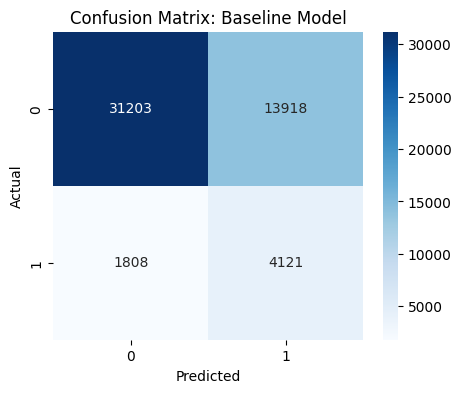

In [24]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Baseline Model')
plt.show()

In [25]:
thresholds = np.arange(0.1, 0.6, 0.05)

results = []
for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    results.append((
        t,
        precision_score(y_test, y_pred_thresh),
        recall_score(y_test, y_pred_thresh),
        f1_score(y_test, y_pred_thresh)
    ))

pd.DataFrame(results, columns=['Threshold','Precision','Recall','F1'])

,Threshold,Precision,Recall,F1
0,0.10,0.119124,0.995952,0.212797
1,0.15,0.125458,0.986844,0.222615
2,0.20,0.133733,0.969809,0.235054
3,0.25,0.143635,0.942655,0.249286
4,0.30,0.155858,0.908416,0.266067
5,0.35,0.170603,0.867431,0.285128
6,0.40,0.187866,0.817844,0.305545
7,0.45,0.207210,0.762017,0.325821
8,0.50,0.228449,0.695058,0.343875
9,0.55,0.252640,0.617473,0.358570


Handling imbalance requires BOTH:
1. Model-level adjustment (class weights)
2. Decision-level adjustment (threshold tuning)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train_transformed, y_train)

y_pred_rf = rf_model.predict(X_test_transformed)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.8851714005876592
Precision: 0.636734693877551
Recall: 0.026311350986675662
F1 Score: 0.05053449951409135
ROC-AUC: 0.7313139457412706


In [28]:
thresholds = np.arange(0.1, 0.6, 0.05)

results_rf = []

for t in thresholds:
    y_pred_thresh = (y_proba_rf >= t).astype(int)
    
    results_rf.append((
        t,
        precision_score(y_test, y_pred_thresh),
        recall_score(y_test, y_pred_thresh),
        f1_score(y_test, y_pred_thresh)
    ))

rf_results_df = pd.DataFrame(
    results_rf, 
    columns=['Threshold','Precision','Recall','F1']
)

rf_results_df

,Threshold,Precision,Recall,F1
0,0.10,0.189910,0.745994,0.302748
1,0.15,0.258202,0.532299,0.347730
2,0.20,0.312245,0.374599,0.340592
3,0.25,0.367159,0.255692,0.301452
4,0.30,0.425825,0.171867,0.244893
5,0.35,0.481481,0.111823,0.181495
6,0.40,0.540506,0.072019,0.127102
7,0.45,0.618304,0.046720,0.086875
8,0.50,0.636735,0.026311,0.050534
9,0.55,0.691176,0.015854,0.030998


Despite the expectation that tree-based models would perform better due to non-linear relationships, Logistic Regression outperformed Random Forest after feature engineering. This indicates that engineered features successfully captured non-linear patterns, making the problem more linearly separable.